In [1]:
import xgi
import numpy as np
from tqdm import tqdm
import pickle
from had_model import HAD_model
import matplotlib.pyplot as plt

In [7]:
epsilons = np.linspace(0., 0.4, num=17)[1:]
iterations = 20  # numbers of iteration for each epsilon
cond = 'std'     # model condition for agreement

Ns = [500, 1000, 2000, 5000]
Ms = [2, 4, 6]
k_avg = 10

ncc = dict()
scc1 = dict()
scc2 = dict()
nhe = dict()
s_avg = dict()
s_max = dict()

for M in Ms:
    for N in Ns:
        
        # All below quantities are computed at the steady state, as a function of epsilon, averaged over 'iterations'
        ncc[f'{M}_{N}'] = []      # number of connected components
        scc1[f'{M}_{N}'] = []     # size of the largest connected component
        scc2[f'{M}_{N}'] = []     # size of the second largest connected component
        nhe[f'{M}_{N}'] = []      # number of hyperedges
        s_avg[f'{M}_{N}'] = []    # average hyperedge size
        s_max[f'{M}_{N}'] = []    # max hyperedge size
                      
        for eps in tqdm(epsilons):
        
            ncc_it = []
            scc1_it, scc2_it = [], []
            nhe_it = []
            s_avg_it, s_max_it = [], []
            
            for it in range(iterations):
                
                H = xgi.uniform_erdos_renyi_hypergraph(N, M, k_avg, p_type="degree")
                H.cleanup()
                tag = f'ER{M}_{N}_{k_avg}'
                groups_0 = H.edges.members()
                
                Model = HAD_model(eps, groups_0)
                results = Model.simulate(condition=cond)
                opinions = results['opinions']
                groups = results['groups']
                
                # number of connected components and size of the two largest
                hedges = groups[-1]
                h = xgi.Hypergraph(hedges)
                # list of connected components
                cc = [j for j in xgi.connected_components(h)]
                ncc_it.append( len(cc) )                    
                scc = set([len(i) for i in cc])
                scc1_it.append( max(scc) / N )
                scc.remove(max(scc))
                if scc:
                    scc2_it.append( max(scc) / N )
                else:
                    scc2_it.append(0)
        
                # relative number of hyperedges
                nhe_it.append( len(groups[-1]) / len(groups_0) )
                
                # relative avg and std of hyperedge sizes
                sizes_end_it = [len(e) for e in groups[-1]]
                s_avg_it.append( np.mean(sizes_end_it) )
                s_max_it.append( np.max(sizes_end_it) )
                
            ncc[f'{M}_{N}'].append(np.mean(ncc_it))
            scc1[f'{M}_{N}'].append(np.mean(scc1_it))
            scc2[f'{M}_{N}'].append(np.mean(scc2_it))
            nhe[f'{M}_{N}'].append(np.mean(nhe_it))
            s_avg[f'{M}_{N}'].append(np.mean(s_avg_it))
            s_max[f'{M}_{N}'].append(np.mean(s_max_it))

# save results
results = {
    'epsilons': epsilons,
    'ncc': ncc,
    'scc1': scc1,
    'scc2': scc2,
    'nhe': nhe,
    's_avg': s_avg,
    's_max': s_max
    }
with open(f'../results/ER_{cond}.pkl', 'wb') as fp:
    pickle.dump(results, fp)

100%|███████████████████████████████████████████| 16/16 [00:46<00:00,  2.93s/it]


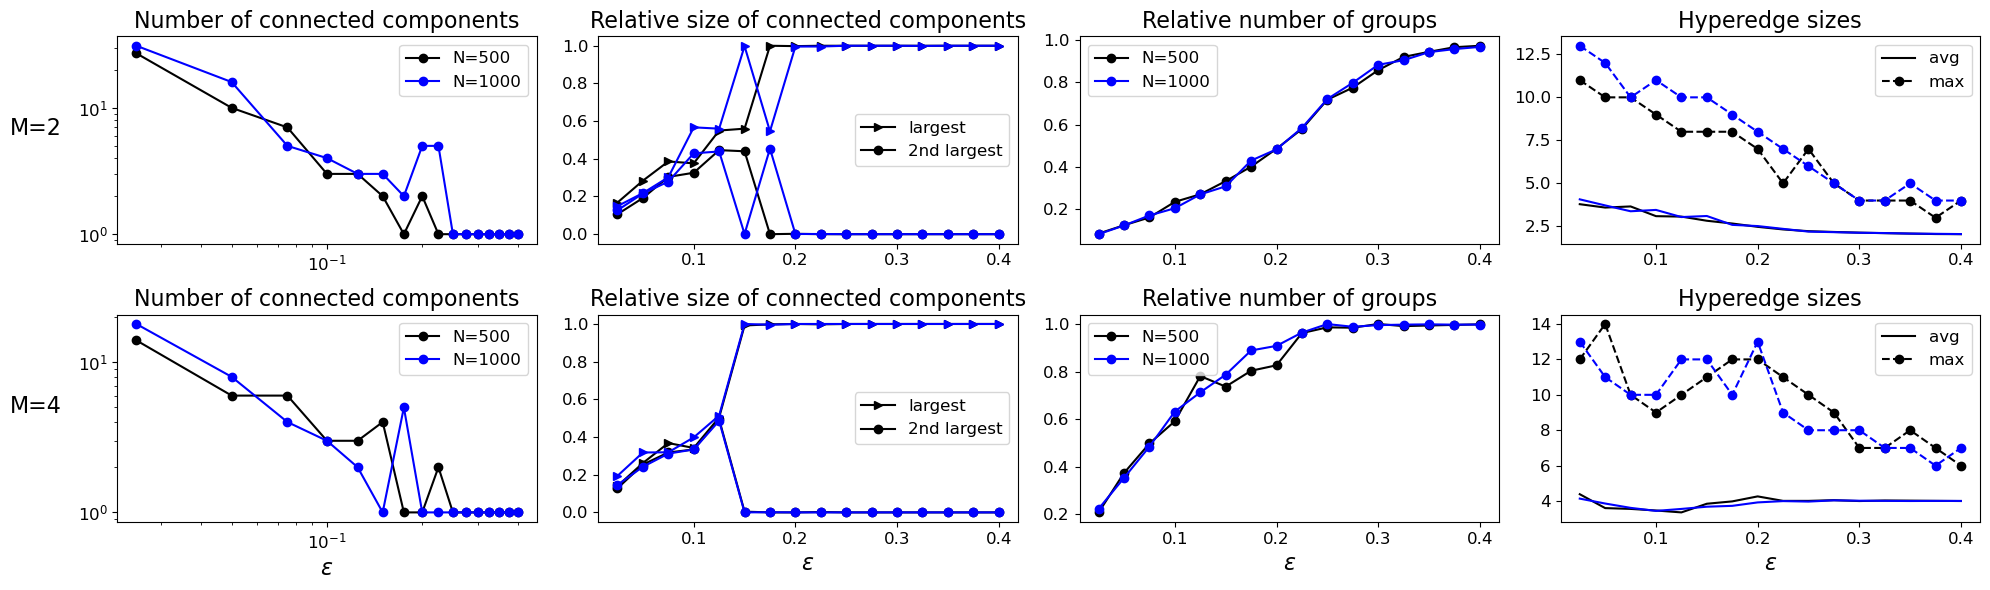

In [41]:
cond = 'std'
with open(f'../results/ER_{cond}.pkl', 'rb') as f:
    results = pickle.load(f)
    
epsilons = results['epsilons']
ncc = results['ncc']
scc1 = results['scc1']
scc2 = results['scc2']
nhe = results['nhe']
s_avg = results['s_avg']
s_max = results['s_max']


fig, axs = plt.subplots(len(Ms), 4, figsize=(20, 3*len(Ms)))
ttl_size = 16
lgd_size = 12
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N

for M in Ms:
    lbls = ['largest', '2nd largest', 'avg', 'max']
    for N,clr in zip(Ns, colors):
                                   
        i = Ms.index(M)
        y0 = ncc[f'{M}_{N}']
        y1 = scc1[f'{M}_{N}']
        y2 = scc2[f'{M}_{N}']
        y3 = nhe[f'{M}_{N}']
        y4 = s_avg[f'{M}_{N}']
        y5 = s_max[f'{M}_{N}']
        
        axs[i,0].plot(epsilons, y0, color=clr, marker='o', label=f'N={N}')
        axs[i,0].set_xscale('log')
        axs[i,0].set_yscale('log')
        axs[i,0].legend(fontsize=lgd_size)
        axs[i,0].set_title('Number of connected components', fontsize=ttl_size)
 
        axs[i,1].plot(epsilons, y1, color=clr, linestyle='-', marker='>', label=lbls[0])
        axs[i,1].plot(epsilons, y2, color=clr, linestyle='-', marker='o', label=lbls[1])
        axs[i,1].legend(fontsize=lgd_size)
        axs[i,1].set_title('Relative size of connected components', fontsize=ttl_size)
        
        axs[i,2].plot(epsilons, y3, color=clr, marker='o', label=f'N={N}')
        axs[i,2].legend(fontsize=lgd_size)
        axs[i,2].set_title('Relative number of groups', fontsize=ttl_size)
        
        axs[i,3].plot(epsilons, y4, label=lbls[2], color=clr)
        axs[i,3].plot(epsilons, y5, label=lbls[3], linestyle='--', marker='o', color=clr)
        axs[i,3].legend(fontsize=lgd_size)
        axs[i,3].set_title('Hyperedge sizes', fontsize=ttl_size)

        # set tick fontsize in all subplots
        for j in range(4):
            axs[i,j].tick_params(labelsize=12)
        lbls = [None for jj in lbls]

    axs[i,0].set_ylabel(f'M={M}', rotation=0, fontsize=ttl_size, labelpad=30)

for j in range(4):
    axs[len(Ms)-1, j].set_xlabel(r'$\epsilon$', fontsize=ttl_size)

plt.tight_layout()
plt.savefig(f'../figures/ER_{cond}.jpg')
plt.show()